# Abstract Classification
In this notebook we aim to develop a classification model regarding NLP. Our goal is to predict whether a given paper abstract concerns about Machine Learning.

In [1]:
import pandas as pd
import numpy as np
import nltk
from datetime import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import functions_aux as f
from joblib import dump, load
import visuals

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='white')

# magic command to reload modules
%load_ext autoreload
%autoreload 2

In [2]:
brz_path = 'bronze/abs_classification'
slv_path = 'silver/abs_classification'
model_path = 'models/abs_classification'


df = pd.read_json(f'{brz_path}/classified_abstracts.json')
df

,DOI,Abstract,Label
0,10.1155/2021/1071145,Forward-looking forecasting of the inflation r...,1
1,10.1007/s43546-022-00384-2,Our study examined the disaggregation of infla...,1
2,10.1002/for.2667,This paper develops a dynamic factor model tha...,0
3,10.1007/s42973-021-00091-x,"In this paper, I use a simple SIR Macro model ...",0
4,10.1007/s40258-012-0003-z,BackgroundGame theory is useful for identifyin...,0
...,...,...,...
1133,10.1007/bf00123887,Concluding remarksWhile the final version of t...,0
1134,10.1093/acrefore/9780190625979.013.171,High-Dimensional Dynamic Factor Models have th...,0
1135,10.1287/mnsc.2013.1812,"Francesca Gino, Erin L. Krupka, Roberto A. Web...",0
1136,10.2118/22022-pa,"Summary EOR projects, notably CO2 floods, are ...",0


## EDA and Feature Engineering
Firstly, we observe four duplicates and 1 missing value in DOI. We remove them all.

In [3]:
df = df.drop_duplicates(subset='DOI')
df.isnull().sum()

DOI         1
Abstract    0
Label       0
dtype: int64

In [4]:
df = df[~df['DOI'].isna()]

In [12]:
aux = df['Label'].value_counts()
display(aux)

display(aux / len(df))

Label
0    900
1    234
Name: count, dtype: int64

Label
0    0.793651
1    0.206349
Name: count, dtype: float64

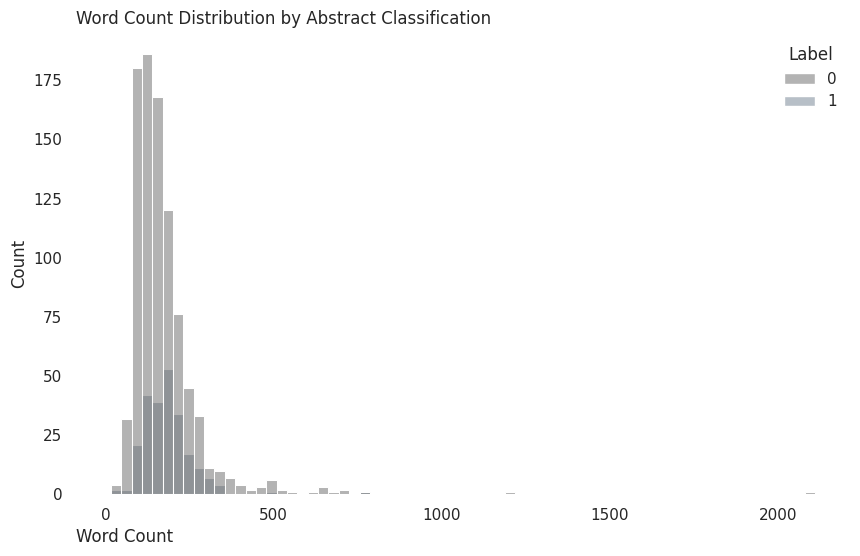

In [5]:
df['n_chars'] = df['Abstract'].str.len()  # number of characters, including blank space
df['word_count'] = df['Abstract'].str.split(' ').str.len()  # word count
df['Abstract'] = df['Abstract'].str.lower()


plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x='word_count',
    hue='Label',
    palette=['dimgrey', 'slategrey']
)
plt.title(
    'Word Count Distribution by Abstract Classification',
    loc='left'
)
plt.xlabel('Word Count', loc='left')
plt.box(False)

## Baseline
As an immediate baseline, we can simply check if the abstract contains the string 'machine learning' and predict it as 1 if positive and 0 if negative. This way, we get 64 out of 234.

In [6]:
df['contains_ML'] = df['Abstract']\
    .str.contains('machine learning')\
    .astype(int)

df[['contains_ML', 'Label']].groupby('Label').sum()

,contains_ML
Label,
0,0
1,64


As we are dealing with a classification problem, it is interesting to consider metrics from the consufion matrix, such as recall, precision, F1, and accuracy. Particularly, since we have an imbalanced dataset (20% of positive values), we shall pay more attention to metrics that give more weight to the positive class, like precision, recall, and F1 score. Below is the confusion metrics for our baseline.

In [7]:
cnfn_metrics = {}
cnfn_metrics['baseline'] = f.get_confusion_metrics(df, 'Label', 'contains_ML')

pd.DataFrame(cnfn_metrics)

,baseline
tpr,0.273504
tnr,1.000000
fpr,0.000000
fnr,0.726496
npv,0.841121
acc,0.850088
ppv,1.000000
f1,0.429530


From them, we get:

1. Only 27% of actual positives were caught (TPR, also known as recall)
2. We never misclassified a negative as positive (TNR, also known as specificity)
3. No false positives (FPR; consistent with the keyword being overly strict)
4. Every positive we predicted really is one (PPV, also known as precision)
5. Good accuracy, but is inflated by class imbalance (many negatives)
6. 43% of F1 score reflects the precision x recall trade-off, where low recall drags it down

The considerations above suggest that many abstracts refer to the positive class implicitly, through synonyms, like deep learning, artificial intelligence, predictive model, or related phrasing. We can thus extend our baseline to include such synonyms or related keywords.

### Stronger Baseline

In [8]:
df['contains_DL'] = df['Abstract']\
    .str.contains('deep learning')\
    .astype(int)

df['contains_NN'] = df['Abstract']\
    .str.contains('neural network')\
    .astype(int)

df['contains_AI'] = df['Abstract']\
    .str.contains('artificial intelligence')\
    .astype(int)

df['contains_PM'] = df['Abstract']\
    .str.contains('predictive model')\
    .astype(int)

df['baseline_pred'] = (
    df[[
        'contains_ML', 'contains_DL',
        'contains_NN', 'contains_AI',
        'contains_PM'
    ]].any(axis=1)
).astype(int)

df.head()

,DOI,Abstract,Label,n_chars,word_count,contains_ML,contains_DL,contains_NN,contains_AI,contains_PM,baseline_pred
0,10.1155/2021/1071145,forward-looking forecasting of the inflation r...,1,1502,211,0,1,1,0,1,1
1,10.1007/s43546-022-00384-2,our study examined the disaggregation of infla...,1,1218,188,1,0,0,0,0,1
2,10.1002/for.2667,this paper develops a dynamic factor model tha...,0,1083,156,0,0,0,0,0,0
3,10.1007/s42973-021-00091-x,"in this paper, i use a simple sir macro model ...",0,1251,194,0,0,0,0,0,0
4,10.1007/s40258-012-0003-z,backgroundgame theory is useful for identifyin...,0,1576,209,0,0,0,0,0,0


In [9]:
cnfn_metrics['baseline'] = f.get_confusion_metrics(df, 'Label', 'baseline_pred')
pd.DataFrame(cnfn_metrics)

,baseline
tpr,0.478632
tnr,0.995556
fpr,0.004444
fnr,0.521368
npv,0.880157
acc,0.888889
ppv,0.965517
f1,0.640000


These new numbers show that nearly twice as many true positives are being caught (21 percentage points increase on TPR) with nearly perfect precision (97% of PPV). The former results on a massive gain on F1 score: 64%.

This demonstrates that many relevant abstracts do not mention Machine Learning directly, but use related phrases. As FPR remains practically 0, our keywords show to be precise. In other words, still, we are now retrieving half of all true positives, with almost perfect precision. Our learned model now has a great baseline to beat.

In [17]:
df.to_csv(f'{slv_path}/abs_classification.csv', index=False)

In [18]:
df = pd.read_csv(f'{slv_path}/abs_classification.csv')
df

,DOI,Abstract,Label,n_chars,word_count,contains_ML,contains_DL,contains_NN,contains_AI,contains_PM,baseline_pred
0,10.1155/2021/1071145,forward-looking forecasting of the inflation r...,1,1502,211,0,1,1,0,1,1
1,10.1007/s43546-022-00384-2,our study examined the disaggregation of infla...,1,1218,188,1,0,0,0,0,1
2,10.1002/for.2667,this paper develops a dynamic factor model tha...,0,1083,156,0,0,0,0,0,0
3,10.1007/s42973-021-00091-x,"in this paper, i use a simple sir macro model ...",0,1251,194,0,0,0,0,0,0
4,10.1007/s40258-012-0003-z,backgroundgame theory is useful for identifyin...,0,1576,209,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
1129,10.1007/bf00123887,concluding remarkswhile the final version of t...,0,3689,538,0,0,0,0,0,0
1130,10.1093/acrefore/9780190625979.013.171,high-dimensional dynamic factor models have th...,0,3655,558,0,0,0,0,0,0
1131,10.1287/mnsc.2013.1812,"francesca gino, erin l. krupka, roberto a. web...",0,14076,2111,0,0,0,0,0,0
1132,10.2118/22022-pa,"summary eor projects, notably co2 floods, are ...",0,4496,695,0,0,0,0,0,0


## Pipeline with CountVectorizer

In [10]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

### Train/Validation/Test Split
We will split our dataset into 70%/15%/15%. As `train_test_split` only divides into two parts each time, we will create the splits in two stages. The first will split the 100% dataset into 85%/15%: 15% for the test set, `X_test` and `y_test`, and the remaining 85% into a temporary dataset, `X_temp`, `y_temp`, later to be spllited once again into the training and validation sets. Consider, however, that in order to obtain 15% of the *total* dataset, we must evaluate the new splitting ratio: $0.85x = 0.15$, to be $x \approx$ 0.1765. Therefore, we split `X_temp` and `y_temp` into two, training and validation sets, with `test_size` = 0.1765.

In [13]:
X = df['Abstract'].copy()
y = df['Label'].copy()


SEED = 1

# keep a holdout test set for final evaluation
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED
)

# use the remaining for training + CV
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=SEED
)

print(f'Training set size: {len(X_train)}')
print(f'Validation set size: {len(X_val)}')
print(f'Test set size: {len(X_test)}')

Training set size: 793
Validation set size: 170
Test set size: 171


### Pipeline, CV and GridSearchCV

In [ ]:
pipeline = Pipeline([
    ('vect', CountVectorizer(stop_words='english')),
    ('lr', LogisticRegression(random_state=SEED, class_weight='balanced'))
])

param_grid = {
    'vect__ngram_range': [(1,1), (1,2)],          # unigrams or up to bigrams
    'vect__min_df': [1, 2, 5],                    # drop very rare tokens
    'vect__max_df': [0.9, 0.95, 1.0],             # drop very frequent tokens (as fraction)
    'vect__max_features': [5000, 10000, None],    # limit vocab size
    'vect__binary': [False, True],                # use presence/absence vs counts
    'lr__C': [0.1, 1.0, 5.0],                     # regularization inverse strength
    'lr__solver': ['liblinear', 'saga', 'lbfgs']  # optimization algorithm
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
)
grid.fit(X_train, y_train)

,estimator,Pipeline(step...om_state=1))])
,param_grid,"{'lr__C': [0.1, 1.0, ...], 'lr__solver': ['liblinear', 'saga', ...], 'vect__binary': [False, True], 'vect__max_df': [0.9, 0.95, ...], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [36]:
print("Best params:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

Best params: {'lr__C': 5.0, 'lr__solver': 'liblinear', 'vect__binary': True, 'vect__max_df': 0.9, 'vect__max_features': 5000, 'vect__min_df': 1, 'vect__ngram_range': (1, 2)}
Best CV F1: 0.7617190076309946


In [37]:
best = grid.best_estimator_

dump(best, f'{model_path}/lr.pkl')

['models/abs_classification/lr.pkl']

In [11]:
lr = load(f'{model_path}/lr.pkl')

In [14]:
y_pred = lr.predict(X_val)

df_val = df[df.index.isin(X_val.index)]
df_val['pred_val'] = y_pred

cnfn_metrics['vect_val'] = f.get_confusion_metrics(df_val, 'Label', 'pred_val')
cnfn_metrics['baseline_val'] = f.get_confusion_metrics(df_val, 'Label', 'baseline_pred')

y_pred = lr.predict(X_test)

df_test = df[df.index.isin(X_test.index)]
df_test['pred_test'] = y_pred

cnfn_metrics['vect_test'] = f.get_confusion_metrics(df_test, 'Label', 'pred_test')
cnfn_metrics['baseline_test'] = f.get_confusion_metrics(df_test, 'Label', 'baseline_pred')

pd.DataFrame(cnfn_metrics)

,baseline,vect_val,baseline_val,vect_test,baseline_test
tpr,0.478632,0.114286,0.400000,0.057143,0.514286
tnr,0.995556,0.837037,0.985185,0.808824,1.000000
fpr,0.004444,0.162963,0.014815,0.191176,0.000000
fnr,0.521368,0.885714,0.600000,0.942857,0.485714
npv,0.880157,0.784722,0.863636,0.769231,0.888889
acc,0.888889,0.688235,0.864706,0.654971,0.900585
ppv,0.965517,0.153846,0.875000,0.071429,1.000000
f1,0.640000,0.131148,0.549020,0.063492,0.679245


### Threshold Tuning: Validation Set
We will use the hold-out validation set, `X_val` and `y_val`, to tune the decision threshold: the cut-off point on the predicted probability above which one classifies a sample as "positive" (in our case, the abstract subject is related to Machine Learning). By default, Logistic Regression uses threshold = 0.5, but we can adjust it depending on our priorities.

We first predict the probabilities on the validation set and then evaluate across a range of thresholds. Afterwards, we find the best one according to our chosen metric: F1-score.

Observe that we are using the validation set after cross-validation, so as to adjust operational parameters, and not model weights or hyperparameters, and preventing data leakage.

In [29]:
from sklearn.metrics import confusion_matrix, precision_recall_curve, average_precision_score

In [ ]:
# probabilities on the validation set
y_pred_val = lr.predict_proba(X_val)[:, 1]

# range of thresholds: 0 to 1 in 100 steps
thresholds = np.linspace(0, 1, 101)
metrics = []

for t in thresholds:
    y_pred_t = (y_pred_val >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred_t).ravel()

    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1  = 2 * (ppv * tpr) / (ppv + tpr) if (ppv + tpr) > 0 else 0

    metrics.append(
        (t, tpr, ppv, f1)
    )

metrics_df = pd.DataFrame(
    metrics,
    columns=['threshold', 'tpr', 'ppv', 'f1']
)
metrics_df.head()

,threshold,tpr,ppv,f1
0,0.00,1.000000,0.205882,0.341463
1,0.01,0.971429,0.400000,0.566667
2,0.02,0.914286,0.470588,0.621359
3,0.03,0.857143,0.526316,0.652174
4,0.04,0.800000,0.528302,0.636364


In [ ]:
# finding the best threshold based on F1-score
best_idx = metrics_df['f1'].idxmax()
best_thr = metrics_df.loc[best_idx, 'threshold']

metrics_df.loc[best_idx]

threshold    0.220000
tpr          0.742857
ppv          0.896552
f1           0.812500
Name: 22, dtype: float64

We can visualize how the metrics change as we vary the threshold. We notice, particularly, that when the threshold is approximately 0.7, we attain PPV = 1, being kept constant until the threshold reaches 1 while TPR and F1 decreases.

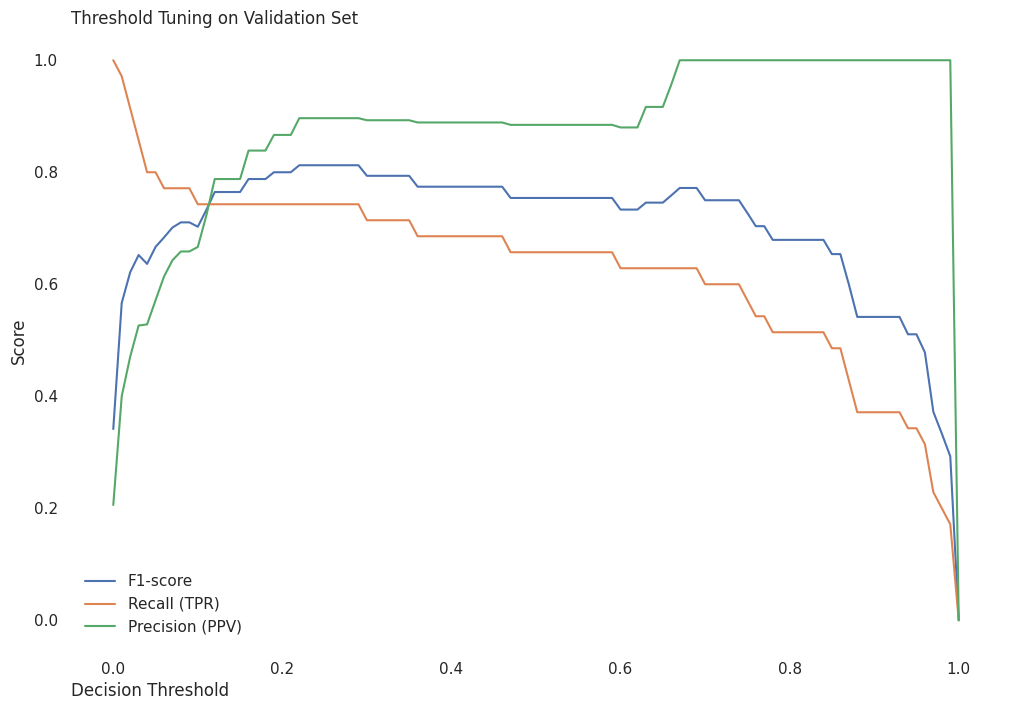

In [35]:
plt.figure(figsize=(12, 8))
plt.plot(metrics_df['threshold'], metrics_df['f1'], label='F1-score')
plt.plot(metrics_df['threshold'], metrics_df['tpr'], label='Recall (TPR)')
plt.plot(metrics_df['threshold'], metrics_df['ppv'], label='Precision (PPV)')
plt.title('Threshold Tuning on Validation Set', loc='left')
plt.xlabel('Decision Threshold', loc='left')
plt.ylabel('Score')
plt.legend()
plt.box(False)

### Precision-Recall Curve
Precision (PPV) cares about false positives, since $$\text{PPV} = \frac{\text{TP}}{\text{TP} + \text{FP}}.$$ A high PPV means a positive result is very likely to be correct, while a low PPV means a positive result is more likely to be a false positive. On the other hand, recall (TPR) cares about false negatives, for $$\text{TPR} = \frac{\text{TP}}{\text{TP} + \text{FN}},$$ and they usually trade-off: if one lowers the decision threshold, one will classify more samples as positive, that is, by increasing recall (finding more true positives), one lowers precision (by catching more false positives).

The PR curve puts them together and is particularly useful in imbalanced situations (where the positive class is rare), since a model can achieve great ROC-AUC, simply by correcting classifying the majority class, while keeping its precision low, meaning that most predicted positives are actually incorrect. Hence, the PR curve directly focuses on how well the model can predict the minority class, by ignoring true negatives, which dominates in imbalance, and by telling us how reliable the positive predictions are. The are under the curve (called average precision) summarizes the trade-off.

In our case, do we prefer to catch all ML papers even if some are false alarms? That is the kind of question the PR curve helps one to answer. For example, we observe that PPV remains at 100% until TPR reaches approximately 60%. This means that one can be extremely confident that the abstract is indeed about Machine Learning and, in this high-precision region, we are covering about 60% of all relevant cases, as we have some false negatives. Thus, we are classifying fewer abstracts, but they all will be correct. Consequently, we could, for instance, automate labeling for top confident cases (zero false positives), then send the remaining 40% for manual review or secondary processing. At the cost of a broader coverage (increasing TPR, by lowering threshold), we start introducing false positives and, thus, PPV starts to drop.

When choosing to optimize F1-score, we are balancing between automation and discovery: a good balance between coverage and correctness.

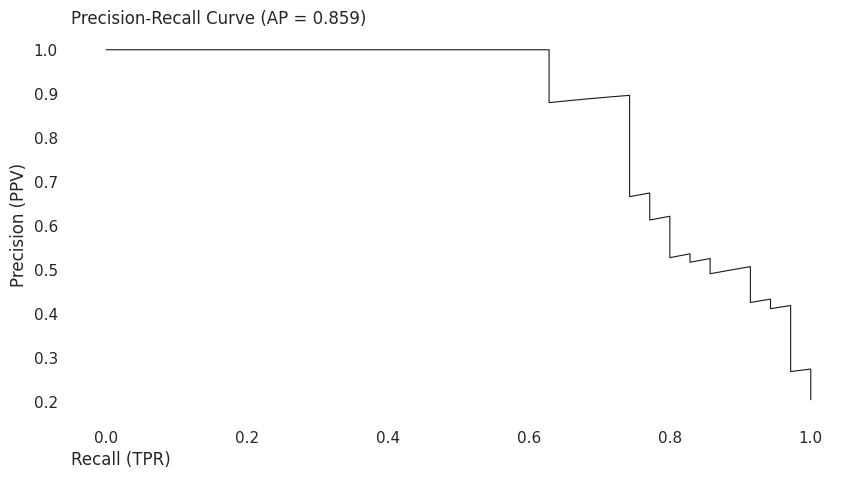

In [39]:
ppvs, tprs, thresholds = precision_recall_curve(y_val, y_pred_val)
avg_p = average_precision_score(y_val, y_pred_val)

plt.plot(tprs, ppvs, color='k', lw=.8)
plt.title(f'Precision-Recall Curve (AP = {avg_p:.3f})', loc='left')
plt.xlabel('Recall (TPR)', loc='left')
plt.ylabel('Precision (PPV)')
plt.box(False)

### Evaluation: Test Set

In [37]:
y_prob_test = lr.predict_proba(X_test)[:, 1]
y_pred_test = (y_prob_test >= best_thr).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
f1  = 2 * (ppv * tpr) / (ppv + tpr) if (ppv + tpr) > 0 else 0

print(f'Test Set Evaluation at Threshold = {best_thr:.2f}')
print(f'TPR (Recall): {tpr:.3f}')
print(f'PPV (Precision): {ppv:.3f}')
print(f'F1-score: {f1:.3f}')

Test Set Evaluation at Threshold = 0.22
TPR (Recall): 0.714
PPV (Precision): 0.694
F1-score: 0.704
